## Drone Localisation Simulation
This project is setup to test the simulation of a microphone picking up the sounds of a drone for the purposes of localisation.



In [ ]:
# !pip install pyroomacoustics numpy scipy==1.11.1 matplotlib acoular

In [2]:
pip install acoular

   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ------------------ --------------------- 2.4/5.0 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 5.0/5.0 MB 12.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------------------------------------- -- 2.6/2.8 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 13.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------- ----------------------- 2.6/6.3 MB 12.6 MB/s eta 0:00:01
   ------------------------------- -------- 5.0/6.3 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 12.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ----------------------- ---------------- 1.3/2.2 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 6.9 MB/s eta 0:00:00
   ------------------------------


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install pyroomacoustics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from numpy import hamming
from scipy.io import wavfile
from IPython.display import Audio, display
from math import floor
import acoular
import os
import h5py
import tables
import time

D:\加拿大\UBC\ENGR 498R Applied Machine Vision for Engineers\lib\site-packages\acoular\__init__.py:10: UserWarning: We detected that Numpy is already loaded and uses OpenBLAS. Because this conflicts with Numba parallel execution, we disable parallel execution for now and processing might be slower. To speed up, either import Numpy after Acoular or set environment variable OPENBLAS_NUM_THREADS=1 before start of the program.
  from .configuration import config


## Building the Space

This is where we specify the dimensions of our simulation environment.

              0             1             2             3             4
0  1.256065e-06 -1.817915e-06  7.461782e-07  1.688501e-06 -1.779547e-07
1 -1.341756e-06 -1.286802e-06 -7.759913e-07 -1.050453e-06 -2.282226e-06
2 -1.901051e-06 -7.739295e-07 -8.975093e-07 -1.922603e-06  2.373027e-07
3 -3.474703e-07  9.922585e-07 -1.203450e-06  6.836467e-07  2.223034e-06
4  5.302253e-07 -1.291771e-06  2.114321e-06  2.566436e-06 -5.214332e-07


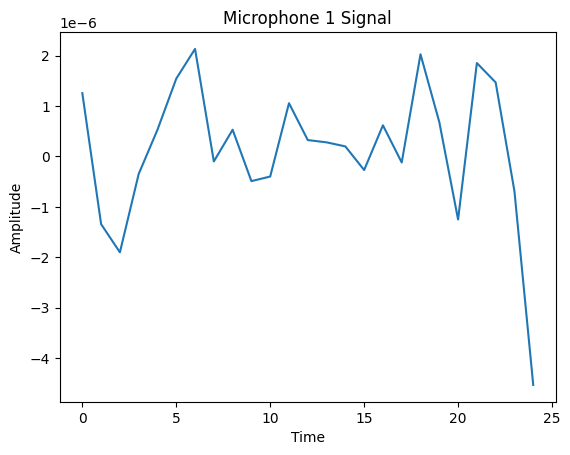

In [15]:
import numpy as np
import pyroomacoustics as pra
from scipy.io import wavfile
import matplotlib.pyplot as plt
import pandas as pd
mic_signals = room.mic_array.signals  # 保留这一行

# 查看前5个麦克风信号的前500个时间点
df = pd.DataFrame(mic_signals[:500, :5])
print(df.head())

# 可选：绘制第一个麦克风信号
plt.plot(mic_signals[:, 0])
plt.title("Microphone 1 Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()
# Unit conversion
metric_conv = 0.3048

corner_locs = 150.0

corners = np.array(
    [
        [0.0, 0.0],
        [corner_locs, 0.0],
        [corner_locs, corner_locs],
        [0.0, corner_locs]
    ]
).T  # shape will be (2, 4)

# Room dimensions (converted to meters)
corner_locs = 150.0 * metric_conv
h = 9.5 * metric_conv
room_dim = [corner_locs, corner_locs, h]

# Source positions (converted to meters)
source = np.array([[122.45], [122], [4.0]]) * metric_conv
source_noise = np.array([[114], [40], [2.0]]) * metric_conv

# Microphone grid setup
grid_side_length = 5
mic_spacing = 0.15  # already in meters
start_x = 1.0
start_y = 1.0
fixed_z = 1.2

x_coords_1d = np.linspace(start_x, start_x + (grid_side_length - 1) * mic_spacing, grid_side_length)
y_coords_1d = np.linspace(start_y, start_y + (grid_side_length - 1) * mic_spacing, grid_side_length)
X_grid, Y_grid = np.meshgrid(x_coords_1d, y_coords_1d)
all_x_coords = X_grid.flatten()
all_y_coords = Y_grid.flatten()
all_z_coords = np.full(all_x_coords.shape[0], fixed_z)
mic_locs = np.array([all_x_coords, all_y_coords, all_z_coords]) * metric_conv

# Read source signal
fs, s = wavfile.read("drone_audio.wav")

if s.ndim > 1:
    s = s[:, 0]  # Use only the first channel

# Create the room
room = pra.ShoeBox(room_dim, fs=fs, max_order=0)  # Free-field simulation (no reflection)
room.add_source(source, signal=s)
room.add_microphone_array(pra.MicrophoneArray(mic_locs, fs=fs))

# Simulate
room.simulate()


## Displaying the Space

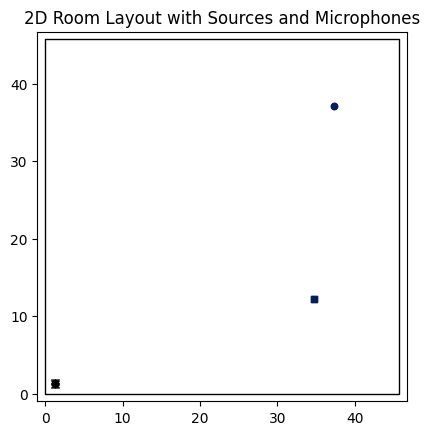

In [17]:
import numpy as np
import pyroomacoustics as pra
import matplotlib.pyplot as plt
from scipy.io import wavfile

# ---- 基本参数 ----
corner_locs = 150.0  # ft
metric_conv = 0.3048  # ft → m

# 定义房间四个角（单位：ft），转置后 shape = (2, 4)
corners = np.array([
    [0.0, 0.0],
    [corner_locs, 0.0],
    [corner_locs, corner_locs],
    [0.0, corner_locs]
]).T * metric_conv  # 转换为米

# 声源位置（单位：m）
source = np.array([[122.45], [122.0], [4.0]]) * metric_conv
source_noise = np.array([[114], [40], [2.0]]) * metric_conv

# ---- 虚拟麦克风阵列参数 ----
grid_side_length = 5
mic_spacing = 0.15  # m
start_x, start_y = 1.0, 1.0  # m
fixed_z = 1.2  # m

# 生成二维网格阵列
x_coords_1d = np.linspace(start_x, start_x + (grid_side_length - 1) * mic_spacing, grid_side_length)
y_coords_1d = np.linspace(start_y, start_y + (grid_side_length - 1) * mic_spacing, grid_side_length)
X_grid, Y_grid = np.meshgrid(x_coords_1d, y_coords_1d)

all_x_coords = X_grid.flatten()
all_y_coords = Y_grid.flatten()
all_z_coords = np.full(all_x_coords.shape[0], fixed_z)
mic_locs = np.array([all_x_coords, all_y_coords, all_z_coords])

# ---- 读取音频（仅用于定义 fs）----
fs, _ = wavfile.read("drone_audio.wav")

# ---- 创建房间并添加元素 ----
room = pra.Room.from_corners(corners, fs=fs)
room.add_source(source[:2])        # 只取X, Y
room.add_source(source_noise[:2])  # 同上
room.add_microphone_array(pra.MicrophoneArray(mic_locs[:2, :], fs=fs))  # 只取平面分布

# ---- 绘图 ----
fig, ax = room.plot(img_order=2)
ax.set_title("2D Room Layout with Sources and Microphones")
ax.set_xlim([-1, np.max(corners[0]) + 1])
ax.set_ylim([-1, np.max(corners[1]) + 1])
plt.show()


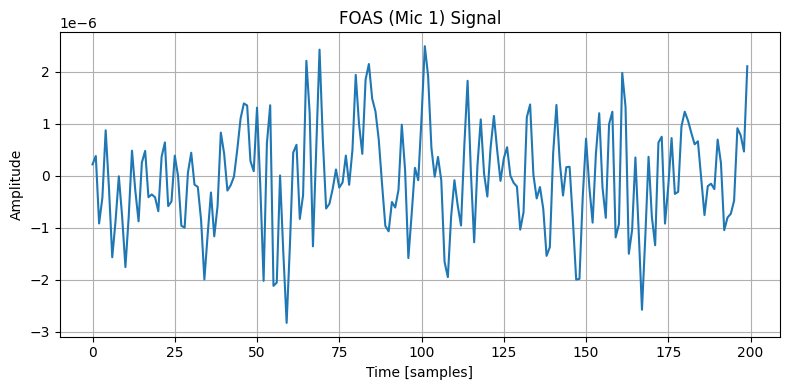

In [18]:
room = pra.ShoeBox(
    [50, 50, 10],        # Room dimensions: 50m x 50m x 10m
    fs=fs,
    max_order=0,         # No reflections (free field)
    absorption=1.0,      # Full absorption (no echo)
    air_absorption=True  # Simulate air attenuation
)

# 添加声源：无人机模拟位置
room.add_source(source.flatten(), signal=s)

# 添加光纤声学传感器阵列（FoAS 作为麦克风阵列模拟）
room.add_microphone_array(pra.MicrophoneArray(mic_locs, fs=fs))

# -------------------------------
# 执行仿真
# -------------------------------
room.simulate()
mic_signals = room.mic_array.signals  # 形状为 (num_mics, num_samples)

# -------------------------------
# 可视化一个 FOAS 通道信号
# -------------------------------
plt.figure(figsize=(8, 4))
plt.plot(mic_signals[0][:200])  # 显示第一个传感器的前200个采样点
plt.title("FOAS (Mic 1) Signal")
plt.xlabel("Time [samples]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

Apt install follow gazebo and ROS2

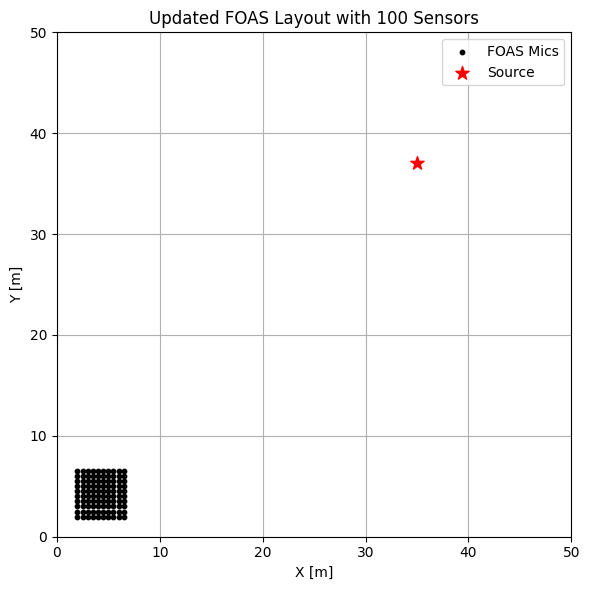

In [1]:
import numpy as np
import pyroomacoustics as pra
import matplotlib.pyplot as plt

# Step 1: Define new larger FOAS array
grid_side_length = 10      # 10x10 grid
mic_spacing = 0.5          # 0.5 meter spacing
start_x, start_y = 2.0, 2.0

# Create grid of microphone positions
x_coords = start_x + mic_spacing * np.arange(grid_side_length)
y_coords = start_y + mic_spacing * np.arange(grid_side_length)
xv, yv = np.meshgrid(x_coords, y_coords)
mic_positions = np.vstack([xv.ravel(), yv.ravel(), np.zeros_like(xv).ravel()])  # 3D locations, z=0

# Room parameters
room_dim = [50, 50, 10]
fs = 16000  # Assumed sampling frequency (should match .wav later)

# Define sound source (fixed position for now)
source = np.array([35.0, 37.0, 1.5])
s = np.random.randn(32000) * 0.01  # placeholder signal

# Define and simulate room
room = pra.ShoeBox(
    room_dim,
    fs=fs,
    max_order=0,
    absorption=1.0,
    air_absorption=True
)
room.add_source(source, signal=s)
room.add_microphone_array(pra.MicrophoneArray(mic_positions, fs=fs))
room.simulate()
mic_signals = room.mic_array.signals

# Plot updated 2D layout
plt.figure(figsize=(6, 6))
plt.scatter(mic_positions[0], mic_positions[1], c='k', s=10, label="FOAS Mics")
plt.scatter(source[0], source[1], c='r', marker='*', s=100, label="Source")
plt.xlim(0, 50)
plt.ylim(0, 50)
plt.title("Updated FOAS Layout with 100 Sensors")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


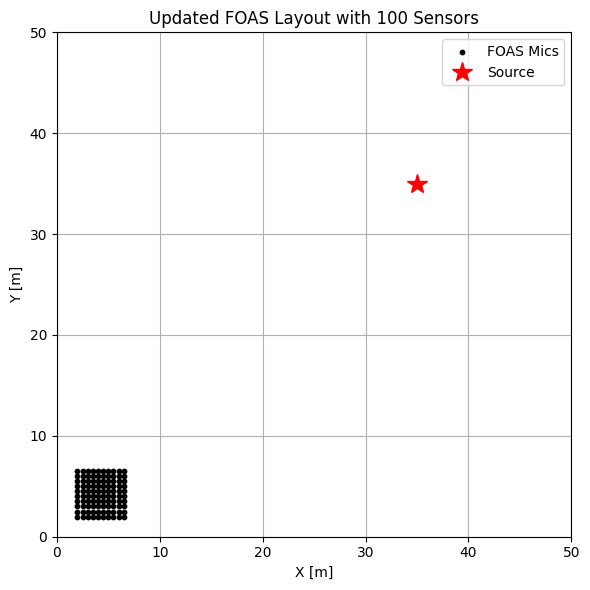

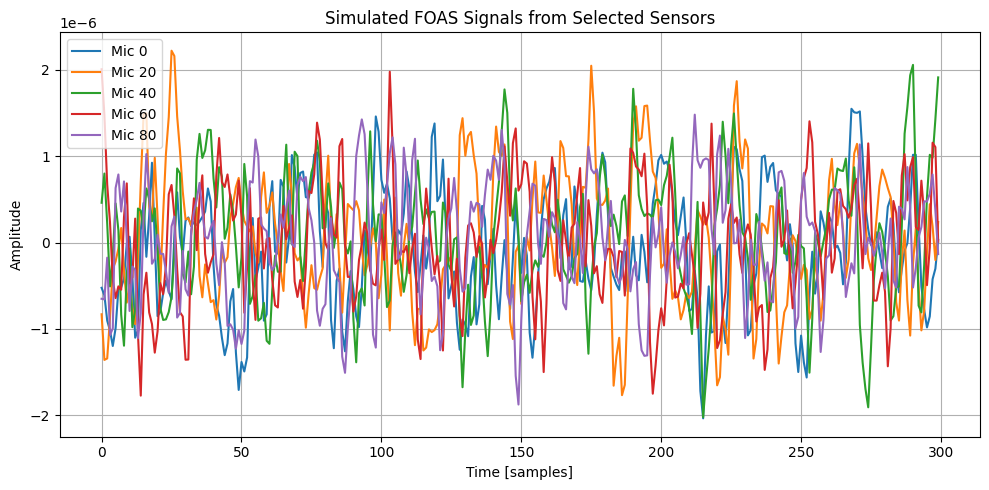

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from scipy.io import wavfile

# --------------------------------------------
# Step 1: 准备音频信号
# --------------------------------------------
fs, audio = wavfile.read("drone_audio.wav")
if audio.ndim > 1:
    audio = np.mean(audio, axis=1)  # 转换为单声道

# --------------------------------------------
# Step 2: FOAS 和房间参数设定
# --------------------------------------------
room_dim = [50, 50, 10]  # 自由场空间（大尺度，避免反射）
source_position = np.array([35, 35, 1.5])  # 声源位置

# 创建 FOAS 阵列（10x10 个点，模拟光纤阵列）
N = 10
x_start, y_start = 2, 2
spacing = 0.5
foas_mics = np.array([
    [x_start + i * spacing, y_start + j * spacing, 1.5]
    for i in range(N) for j in range(N)
]).T  # shape: (3, 100)

# --------------------------------------------
# Step 3: 构建房间（自由场：全吸收）
# --------------------------------------------
room = pra.ShoeBox(
    room_dim,
    fs=fs,
    max_order=0,         # 无反射
    absorption=1.0,      # 全吸收（模拟 open-field）
    air_absorption=True
)

# 添加信号源 + FOAS 麦克风阵列
room.add_source(source_position, signal=audio)
room.add_microphone_array(pra.MicrophoneArray(foas_mics, fs=fs))

# --------------------------------------------
# Step 4: 仿真并获取信号
# --------------------------------------------
room.simulate()
mic_signals = room.mic_array.signals  # shape: (100, N_samples)

# --------------------------------------------
# Step 5: 可视化布置
# --------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(foas_mics[0], foas_mics[1], s=10, label='FOAS Mics', color='black')
plt.plot(source_position[0], source_position[1], 'r*', markersize=15, label='Source')
plt.xlim(0, room_dim[0])
plt.ylim(0, room_dim[1])
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Updated FOAS Layout with 100 Sensors")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------
# Step 6: 可视化部分 FOAS 信号
# --------------------------------------------
plt.figure(figsize=(10, 5))
for i in [0, 20, 40, 60, 80]:
    plt.plot(mic_signals[i][:300], label=f'Mic {i}')
plt.title("Simulated FOAS Signals from Selected Sensors")
plt.xlabel("Time [samples]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


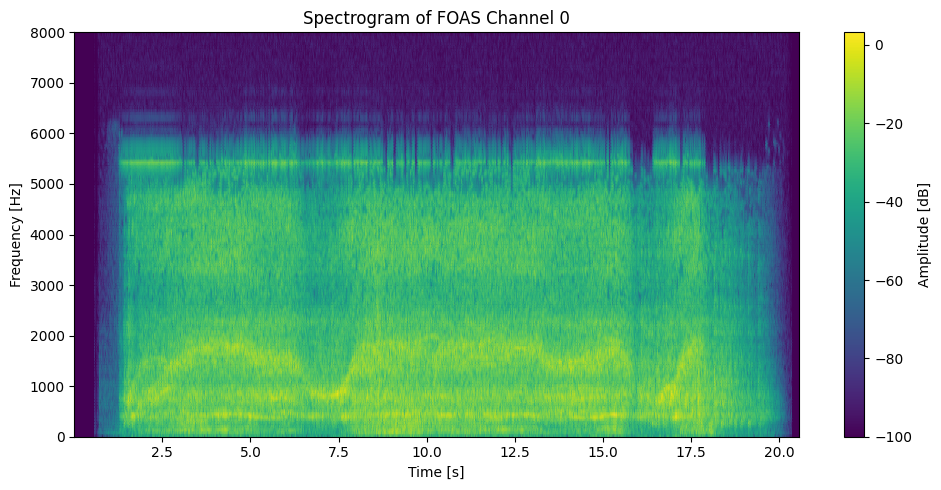

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

fs = 16000  # 假设采样率为 16kHz，如果不同可根据实际调整
signal = mic_signals[0]  # 选择第一个 FOAS 通道

# 计算频谱图
f, t, Sxx = spectrogram(signal, fs=fs, nperseg=256, noverlap=128)

# 转换为 dB 单位
Sxx_dB = 10 * np.log10(Sxx + 1e-10)

# 可视化
plt.figure(figsize=(10, 5))
plt.pcolormesh(t, f, Sxx_dB, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of FOAS Channel 0')
plt.colorbar(label='Amplitude [dB]')
plt.tight_layout()
plt.show()


In [11]:
pip install soundfile

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 3.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
pip install cffi soundfile --force-reinstall

  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   -------- ------------------------------- 2.9/12.9 MB 13.9 MB/s eta 0:00:01
   ----------------- ---------------------- 5.8/12.9 MB 14.1 MB/s eta 0:00:01
   --------------------------- ------------ 8.9/12.9 MB 14.2 MB/s eta 0:00:01
   ------------------------------------ --- 11.8/12.9 MB 14.2 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 14.0 MB/s eta 0:00:00
  Attempting uninstall: pycparser
    Found existing installation: pycparser 2.22
    Uninstalling pycparser-2.22:
      Successfully uninstalled pycparser-2.22
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.0
    Uninstalling numpy-1.26.0:
      Successfully uninstalled numpy-1.26.0
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninst

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import soundfile as sf  # 安装：pip install soundfile

# 保存第一个 FOAS 通道信号为 WAV 文件
sf.write("foas_mic_0.wav", mic_signals[0], samplerate=fs, subtype='PCM_16')


In [15]:
from IPython.display import Audio

Audio("foas_mic_0.wav")